## Density calculation using Equations of State (EoS)
### Cubic EoS
The development of cubic equations of state began in 1873 with the publication of the van der Waals (VdW) equation [1]. Subsequent research gave rise to an important class of equations that share the general form:

<br>

$$P = \frac{RT}{\overline{V}-b}-\frac{a}{(\overline{V}+\epsilon b) (\overline{V}+\sigma b)}$$

$$a = \sum_{i=1}^{C}\sum_{j=1}^{C} x_{i}x_{j}(1 - k_{ij}) \sqrt{a_i a_j}$$

$$b = \sum_{i=1}^{C} x_{i}\Omega \frac{RT_{c,i}}{P_{c,i}}$$

$$a_{i} = \psi \frac{\alpha_{i} R^{2}T_{c,i}^{2}}{P_{c,i}}$$

<br>Such generalization, combined with the appropriate selection of parameters (Table 01), leads to the following:
* van der Waals (VDW);
* Redlich/Kwong (RK);
* Soave/Redlich/Kwong (SRK);
* Peng/Robinson (PR).<br>


<div align="center">

$\textbf{Table 01. Parameters of cubic equations of state}$

| $\text{EoS}$ | $\alpha$ | $\sigma$ | $\epsilon$ | $\Omega$ | $\psi$ |
|---|---:|---:|---:|---:|---:|
| $\text{van der Waals}$ | $1$ | $0$ | $0$ | $\frac{1}{8}$ | $\frac{27}{64}$ |
| $\text{Redlich-Kwong}$ | $T_r^{1/2}$ | $1$ | $0$ | $0.08664$ | $0.42748$ |
| $\text{Soave-Redlich-Kwong}$ | $[1+k_{SRK}(1-T_r^{1/2})]^2$ | $1$ | $0$ | $0.08664$ | $0.42748$ |
| $\text{Peng-Robinson}$ | $[1+k_{PR}(1-T_r^{1/2})]^2$ | $1+\sqrt{2}$ | $1-\sqrt{2}$ | $0.07780$ | $0.45724$ |


</div>



<br>The calculation of the molar volume requires solving the generalized equation of state, which reduces to a cubic polynomial. This cubic equation yields three real roots under vapor–liquid equilibrium conditions. The smallest root corresponds to the liquid phase, while the largest root represents the vapor phase. The intermediate root has no physical meaning and is therefore discarded. Once, molar volume is achived, the density ($\rho$) can be found by:

$$\rho = \frac{MM}{\overline{V}}$$


### Others EoS
It is worth highlighting that the code is designed to be extensible; other equations of state (e.g., PC-SAFT or SAFT-VR Mie) can be coupled by creating new classes for each specific model, like the class ```CubicEoS``` below. This allows the use of functionallities of this code.


### Dependencies

In [1]:
import math
import numpy as np
from collections.abc import Sequence, Mapping
from numpy.typing import NDArray
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from abc import ABC, abstractmethod


### Implementation of cubic equations of state

The cubic equations of state described previously were implemented in the ```CubicEoS``` class in order to consolidate the code and keep it as streamlined as possible. Basically, such class splits the EoS into:

* ```_set_eos_parameters```: It is responsible for calculating some specific parameters ($\sigma$, $\epsilon$, $\alpha_{i}$, $\Omega$, $\psi$), according with selected EoS;
* ```_kij```: Organizes the BIP's into a proper matrix;
* ```_mixture_rule```: Performs the VDW mixture rule for $a$ and $b$;
* ```density```: Performs the density calculation of system, based on the desired phase (liquid or vapor). Such method is using the above methods.


The arguments of this class are:

* ***eos:*** equation of state to be used (all described in the beginning of this notebook);
* ***P:*** Pressure of the system;
* ***T:*** Temperature of the system;
* ***Tc:*** Critical temperature;
* ***Pc:*** Critical pressure;
* ***w:*** Acentric factor;
* ***x:*** Molar fraction;
* ***MM:*** Molar mass;
* ***Kij:*** Binary interaction parameter.

NOTE: Pay close attention to the units of each argument.

In [2]:
class EoS(ABC):
    def __init__(self, eos: str, T: float, P: float, x: NDArray[np.float64], Kij: NDArray[np.float64]) -> None:
        self.eos = eos
        self.T = T
        self.P = P
        self.x = x
        self.Kij = Kij


    def set_temperature(self, T: float) -> None:
        """
        Set the temperature for the EoS calculations.
        """
        self.T = T
    

    def set_eos(self, eos: str) -> None:
        """
        Set the equation of state (EoS) type for the calculations.
          :param eos: Type of EoS (e.g., 'PR', 'SRK', 'VDW', 'RK')
        """
        self.eos = eos.upper()
    

    def set_kij(self, Kij:NDArray[np. float64]) -> None:
        """
        Set the binary interaction parameter (Kij) for the calculations.
          :param kij: Binary interaction parameter (Kij)
        """
        self.Kij = Kij
        
    
    @abstractmethod
    def density(self, phase:str) -> float:
        """This method should be implemented by all EoS classes to calculate the density 
        of the system based on the desired phase."""
        pass


class CubicEoS(EoS):

    eos_name = ['PR', 'SRK', 'VDW', 'RK']

    def __init__(
            self,
            P: float,
            Tc: NDArray[np.float64],
            Pc: NDArray[np.float64],
            w: NDArray[np.float64],
            x: NDArray[np.float64],
            MM: NDArray[np.float64],
            Kij: NDArray[np.float64],
            T: float = 298.15,
            eos: str = 'RK',
    ) -> None:
        super().__init__(eos, T, P, x, Kij)
        self.R = 8.314 #J/mol*K
        self.Tc = Tc
        self.Pc = Pc
        self.w = w
        self.MM = MM


    def _set_eos_parameters(self, T: float, eos: str) -> Sequence[float]:
        """
        Selection of EoS parameters according to the chosen EOS
          :return: sigma, epsilon, alfai, omega, psi
        """
        Tr = T / self.Tc
        if eos.upper() == 'VDW':
            sigma = 0
            epsilon = 0
            alfai = 1
            omega = 1 / 8
            psi = 27 / 64

        elif eos.upper() == 'RK':
            sigma = 1
            epsilon = 0
            alfai = 1 / np.sqrt(Tr)
            omega = 0.08664
            psi = 0.42748

        elif eos.upper() == 'SRK':
            sigma = 1
            epsilon = 0
            K_srki = 0.480 + 1.574 * self.w - 0.176 * (self.w ** 2)
            alfai = (1 + K_srki * (1 - np.sqrt(Tr))) ** 2
            omega = 0.08664
            psi = 0.42748

        elif eos.upper() == 'PR':
            sigma = 1 + np.sqrt(2)
            epsilon = 1 - np.sqrt(2)
            K_pri = 0.37464 + (1.54226 * self.w) - (0.26992 * (self.w ** 2))
            alfai = (1 + K_pri * (1 - np.sqrt(Tr))) ** 2
            omega = 0.07780
            psi = 0.45724

        else:
            raise ValueError(f"Invalid EOS type. Choose from {self._eos}")

        return sigma, epsilon, alfai, omega, psi


    def _kij(self, kij:NDArray[np. float64]) -> NDArray[np. float64]:
        """
        Organization of binary interaction parameter (Kij)
          :return: Kij
        """
        cont = 0
        row = len(self.w)
        column = row
        matrix = np.zeros((row, column))

        for i in range(row):
            for j in range(column):
                if j > i:
                    matrix[i, j] = kij[cont]
                    cont += 1

        matrix_T = np.transpose(matrix)
        matrix_kij = matrix + matrix_T
        Kij = [matrix_kij[i, j] for i in range(row) for j in range(column)]

        return np.array(Kij)


    def _mixture_rule(self):
        """
        Mixture attraction and repulsion coefficients by VdW rule mixture
          :return: a, b, aij, bi
        """
        _, _, alfai, omega, psi = self._set_eos_parameters(self.T, self.eos)
        self.set_kij(self._kij(self.Kij))
        cont = 0
        a = 0
        aij = np.zeros(len(self.w)**2)
        ai = alfai * psi * (self.R ** 2) * (self.Tc ** 2) / self.Pc
        bi = omega * self.R * (self.Tc / self.Pc)
        b = sum(self.x * bi)
        for j in range(len(self.w)):
            for l in range(len(self.w)):
                aij[cont] = (np.sqrt(ai[j] * ai[l]) * (1 - self.Kij[cont]))
                a += self.x[j] * self.x[l] * aij[cont]
                cont += 1

        return a, b, aij, bi


    def density(self, phase:str) -> float:
        """
        Calculation of the system density based on the desired phase.
          :param x: Mol fraction of a given phase
          :param phase: Desired phase
          :return: Density of system
        """
        sigma, epsilon, alfai, _, _ = self._set_eos_parameters(self.T, self.eos)
        a, b, _, _, = self._mixture_rule()
        beta = b*self.P/(self.R*self.T)
        q = a/(b*self.R*self.T)
        c3 = 1
        c2 = ((sigma+epsilon-1)*beta)-1
        c1 = ((epsilon*sigma*beta)-sigma-epsilon-(sigma*beta)-(epsilon*beta)+q)*beta
        c0 = -(((epsilon*sigma)+(epsilon*sigma*beta)+q)*beta**2)
        coefs = [c3, c2, c1, c0]
        z = np.roots(coefs)
        z_real = z[np.isclose(z.imag, 0.0, atol=1e-9)].real
        vol_real = z_real*self.R*self.T/self.P
        MM_mix = np.sum(self.MM*self.x)
        if len(vol_real) == 1:
            density = float(MM_mix/vol_real[0])*1e-03
        else:
            if phase == "vapor":
                density = float(MM_mix/np.max(vol_real))*1e-03

            elif phase == "liquid":
                density = float(MM_mix/np.min(vol_real))*1e-03
            else:
                raise TypeError("Such phase doesn't exist!")
        
        return density


### Auxiliary functions

Here are presented the auxiliary functions to be used for the main functions. They are split into:

* ```_create_temperature_range```: Create a temperature range for density calculations based on the experimental temperatures and user preference;
* ```_density_calculation_without_kij_estimation```: calculates the density for multiple temperature points, but without estimate kij;
* ```_optimization_Kij```: optimizes the Kij for a set of experimental data;
* ```_density_calculation_with_kij_estimation```: calculates the density for multiple temperature points, using calculated kij;

In [3]:
def _create_temperature_range(experimental_temperatures: Sequence[float], 
    use_experimental_temperatures: bool) -> Sequence[float]:
    """
    Create a temperature range for density calculations based on the experimental temperatures and user preference.
      :param experimental_temperatures: Sequence of experimental temperatures
      :param use_experimental_temperatures: Flag to determine whether to use experimental temperatures or create a range
      :return: Sequence of temperatures for density calculations
    """
    if not use_experimental_temperatures:
        temperatures = np.linspace(min(experimental_temperatures),
                                      max(experimental_temperatures), 100)
    else:
        temperatures = experimental_temperatures

    return temperatures


def _density_calculation_without_kij_estimation(
    eos_model: EoS,
    phase: str,
    exp_temperature: Sequence[float],
    use_experimental_temperatures: bool = False,
) -> Mapping[str, Sequence[float]]:
    """
    Calculation of the density of system for multiple points
    """
    densities = []
    densities_per_eos = {}
    temperatures = _create_temperature_range(exp_temperature, use_experimental_temperatures)

    for eos in eos_model.eos_name:
        for T in temperatures:
            eos_model.set_eos(eos)
            eos_model.set_temperature(T)
            calculated_density = eos_model.density(phase=phase)
            densities.append(calculated_density)
        densities_per_eos[eos] = densities
        densities = []
    print("Calculation accomplished succesfully!")
    return densities_per_eos


def _optimization_Kij(
    eos_model: EoS,
    phase: str,
    exp_densities: Sequence[float],
    exp_temperature: Sequence[float],
    use_experimental_temperatures: bool = False,
  )->Sequence[float]:

    def calculate_density_for_kij(Kij, eos_model, phase, exp_temperature):
        densities = []
        for T in exp_temperature:
            eos_model.set_kij(Kij)
            eos_model.set_temperature(T)
            calculated_density = eos_model.density(phase=phase)
            densities.append(calculated_density)

        return densities

    def f_obj(Kij, eos_model, phase, exp_densities, exp_temperature):
        densities = calculate_density_for_kij(Kij, eos_model, phase, exp_temperature)
        func = ((np.array(exp_densities)-np.array(densities))
                /np.array(exp_densities))
        return np.sum(func**2)

    n = len(eos_model.x)
    size = math.comb(n, 2)
    x0 = [0.0]*size
    bounds = [(-0.7, 0.7)]*size
    result = minimize(f_obj, x0, args=(eos_model, phase, exp_densities, exp_temperature),
              method='SLSQP', bounds=bounds)

    temperatures = _create_temperature_range(exp_temperature, use_experimental_temperatures)
    return calculate_density_for_kij(np.array(result.x), eos_model, phase, temperatures)


def _density_calculation_with_kij_estimation(eos_model: EoS,
    phase: str,
    exp_densities: Sequence[float],
    exp_temperature: Sequence[float],
    use_experimental_temperatures: bool = False,
  )->Mapping[str, Sequence[float]]:
    """
    Calculation of the density of system for multiple points with Kij estimation
    """
    densities_per_eos = {}
    for eos in eos_model.eos_name:
        eos_model.set_eos(eos)
        densities_per_eos[eos] = _optimization_Kij(eos_model, phase, exp_densities, exp_temperature, use_experimental_temperatures)

    return densities_per_eos


### User-executable functions

Here are presented the functions to be used for the user. They are split into:

* ```plot_deviation```: calculates the mean relative deviation (equation below) for all eos and plot the results
$$MRD = \frac{100}{N}\sum_{i=1}^{N}\left|\frac{\rho_{i}^{calc}-\rho_{i}^{exp}}{\rho_{i}^{exp}}\right|$$
* ```plot_density_versus_temperature```: generates a plot of density versus temperature

In [4]:
def plot_deviation(
    eos_model: EoS,
    phase: str,
    exp_densities: Sequence[float],
    exp_temperature: Sequence[float],
    predictive_form: bool = True,
)->None:
    """
    Generation of a graph of density deviation for each EoS
    from experimental data.
    """
    if predictive_form == False:
        calculated_densities = _density_calculation_with_kij_estimation(
            eos_model,
            phase,exp_densities,
            exp_temperature,
            use_experimental_temperatures=True)
    else:
        calculated_densities = _density_calculation_without_kij_estimation(
            eos_model, phase,
            exp_temperature,
            use_experimental_temperatures=True)

    deviations = {}
    for eos in calculated_densities.keys():
        deviations[eos] = []
        for calculated_density, experimental_density in zip(calculated_densities[eos], exp_densities):
            deviations[eos].append(abs(calculated_density - experimental_density)/experimental_density)

    mean_deviations = {eos: np.mean(values)*100 for eos, values in deviations.items()}
    labels = list(mean_deviations.keys())
    values = list(mean_deviations.values())
    plt.bar(labels, values)
    plt.ylabel("Mean Relative Deviation [%]")
    plt.xlabel("Equation of State")
    plt.title("Deviation per EOS")
    plt.tight_layout()
    plt.show()


def plot_density_versus_temperature(
    eos_model: EoS,
    phase: str,
    exp_densities: Sequence[float],
    exp_temperature: Sequence[float],
    exp_label_text: str,
    predictive_form: bool = True,
) -> None:
  """
  Generation of a graph of experimental and calculated densities
  versus temperature.
  """
  use_experimental_temperatures=False
  temperatures = _create_temperature_range(exp_temperature, 
        use_experimental_temperatures=use_experimental_temperatures)
  if predictive_form == False:
      calculated_densities = _density_calculation_with_kij_estimation(
            eos_model,
            phase,exp_densities,
            exp_temperature,
            use_experimental_temperatures=use_experimental_temperatures)
  else:
      calculated_densities = _density_calculation_without_kij_estimation(
            eos_model, phase,
            exp_temperature,
            use_experimental_temperatures=use_experimental_temperatures)

  plt.plot(exp_temperature, exp_densities, 'ko', label=exp_label_text)

  for eos, densities in calculated_densities.items():
    plt.plot(temperatures, densities, label=f"{eos} EoS")

  plt.xlabel("Temperature [K]")
  plt.ylabel("Density [kg/m³]")
  plt.legend(bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=3, frameon=False)
  plt.tight_layout()
  

### Calculation of densities

#### Gas phase

* Input parameters

In [5]:
# Methane + Propane
pressure = 34.606e06 #Pa
critical_temperature = np.array([190.564, 369.89]) #K
critical_pressure = np.array([4.5992e06, 4.2512e06]) #Pa
acentric_factor = np.array([0.01142, 0.1521])
Kij = np.array([0.0])
mol_fraction=np.array([0.9472, 0.0528])
molar_mass=np.array([16.043, 44.097]) #g/mol

* Experimental data

In [6]:
exp_temperature = [256.10, 311.0, 366.40, 421.52] #K
exp_density = [305.13, 242.27, 195.80, 163.74] #kg/m3

* Density calculation (without kij adjustment)

Calculation accomplished succesfully!


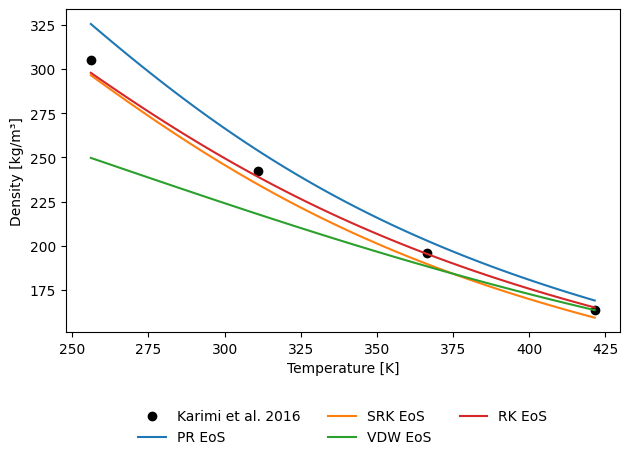

In [7]:
cubic_eos = CubicEoS(
                    P=pressure,
                    Tc=critical_temperature,
                    Pc=critical_pressure,
                    w=acentric_factor,
                    x= mol_fraction,
                    MM = molar_mass,
                    Kij=Kij,
)

plot_density_versus_temperature(
    eos_model=cubic_eos,
    phase="vapor",
    exp_densities=exp_density,
    exp_temperature=exp_temperature,
    exp_label_text="Karimi et al. 2016",
    predictive_form=True
)


Calculation accomplished succesfully!


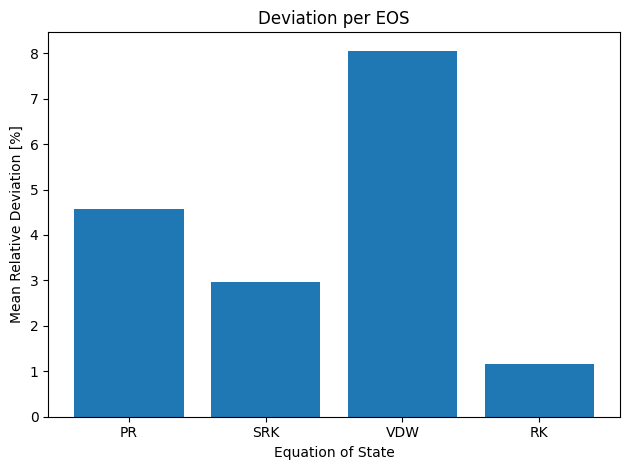

In [8]:
plot_deviation(
    eos_model=cubic_eos,
    phase = "vapor",
    exp_densities = exp_density,
    exp_temperature = exp_temperature,
    predictive_form = True,
)

* Density calculation (with kij adjustment)

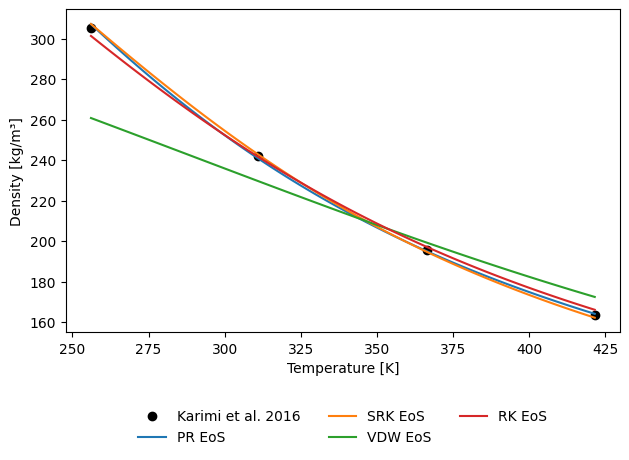

In [9]:
cubic_eos_ = CubicEoS(
                    P=pressure,
                    Tc=critical_temperature,
                    Pc=critical_pressure,
                    w=acentric_factor,
                    x= mol_fraction,
                    MM = molar_mass,
                    Kij=Kij,
)

plot_density_versus_temperature(
    eos_model=cubic_eos_,
    phase = "vapor",
    exp_densities = exp_density,
    exp_temperature = exp_temperature,
    exp_label_text = "Karimi et al. 2016",
    predictive_form = False,
)

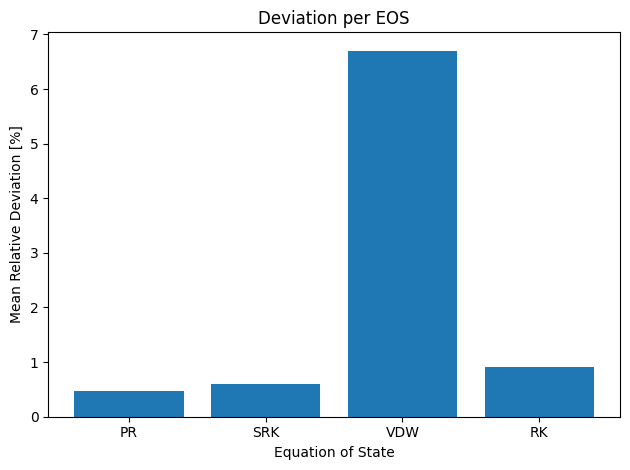

In [10]:
plot_deviation(
    eos_model=cubic_eos_,
    phase = "vapor",
    exp_densities = exp_density,
    exp_temperature = exp_temperature,
    predictive_form = False,
)

#### Liquid phase

* Input parameters

In [11]:
# n-Hexane
pressure = 101325 #Pa
critical_temperature = np.array([507.82]) #K
critical_pressure = np.array([	3.0441e06]) #Pa
acentric_factor = np.array([0.3])
Kij = np.array([0.0])
mol_fraction=np.array([1.0])
molar_mass=np.array([86.18]) #g/mol


* Experimental data

In [12]:
exp_temperature = [273.15, 278.15, 283.15, 288.15,
                   293.15, 298.15, 303.15, 308.15] #K

exp_density = [677.18, 672.79, 668.37, 663.91,
               659.42, 654.89, 650.33, 645.73] #kg/m3

* Density calculation

Calculation accomplished succesfully!


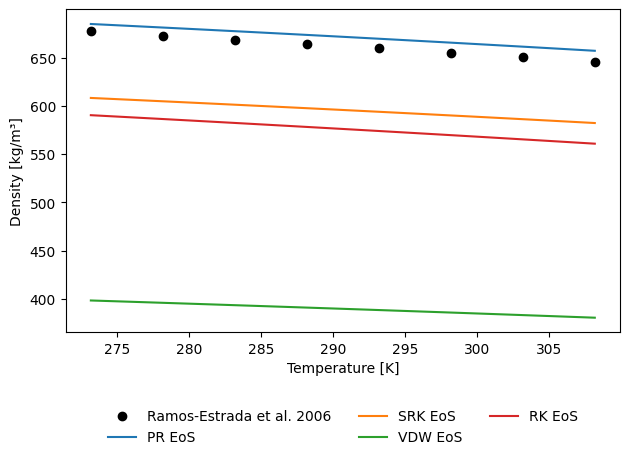

In [13]:
cubic_eos = CubicEoS(
                    P=pressure,
                    Tc=critical_temperature,
                    Pc=critical_pressure,
                    w=acentric_factor,
                    x= mol_fraction,
                    MM = molar_mass,
                    Kij=Kij,
)

plot_density_versus_temperature(
    eos_model=cubic_eos,
    phase = "liquid",
    exp_densities = exp_density,
    exp_temperature = exp_temperature,
    exp_label_text = "Ramos-Estrada et al. 2006",
    predictive_form = True,
)


Calculation accomplished succesfully!


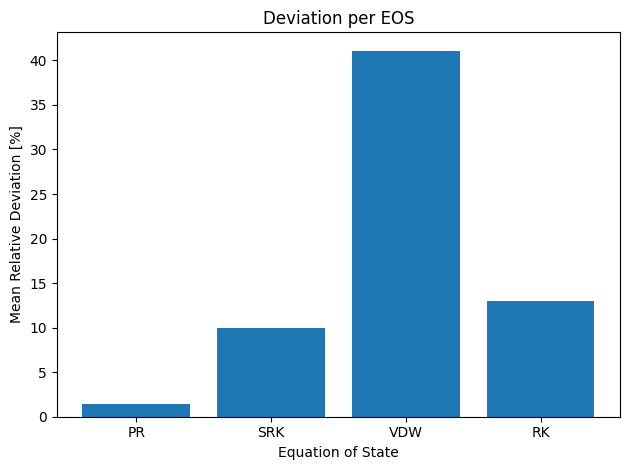

In [14]:
plot_deviation(
    eos_model=cubic_eos,
    phase = "liquid",
    exp_densities = exp_density,
    exp_temperature = exp_temperature,
    predictive_form = True,
)

According with the above graph is possible to see that the calculated density has a good qualitative behavior, once the reduction of density is observed as the temperature of system increases. On the other hand, the quantitative results are not so good in comparision with experimental data. Such result is expected due to the limitations of cubic equations of state for predicting thermodynamic state properties in the liquid phase [2]. In this context, implementation of more sofisticated equations of state (i.g. PC-SAFT and CPA) can provide more accurated results.

### Bonus section

---

**Expanding the Framework**

The architecture allows for easy integration of new Equations of State (EoS). To implement a new model, such as PC-SAFT, you must adhere to the following implementation pattern:

Suppose that user wants to implement the PC-SAFT EoS
```Python
class PCSAFT(EoS):
    eos_name = "pcsaft"

    def __init__(self, T, P, x, Kij, params):
        super().__init__(T, P, x, Kij)
        self.params = params
    
    # Add all necessary methods for this EoS 

    def density(self, phase):
        # Add the specific PC-SAFT implementation here
```

**Key Requirements:**

* **Inheritance**: The new class must inherit from the EoS base class.

* **Attribute naming**: Define a unique ```eos_name``` for identification.

* **Method Implementation**: The density method must be overridden, as it is a core requirement for the simulation suite to function correctly.

* **Parameters**: Ensure that any model-specific constants (like segment diameter or energy parameters) are correctly initialized.

### References
1) Peng, D.; Robinson D. B.. A new Two-Constante Equation of State, Ind. Eng. Chem. Fundam., 1976, vol 15, 59-64;
2) Valderrama, J. O.. The State of the Cubic Equations of State, Ind. Eng. Chem. Res. 2003, 42, 1603-1618;
3) Ramos-Estrada, M.; Iglesias-Silva, G. A.; Hall, K. R.. Experimental measurements and prediction of liquid densities
for n-alkane mixtures, J. Chem. Thermodynamics 38 (2006) 337–347;
4) Karimi, A.; Hughes, T. J.; Richter, M.; May, E. F.. Density Measurements of Methane + Propane Mixtures at
Temperatures between (256 and 422) K and Pressures from
(24 to 35) MPa, J. Chem. Eng. Data 2016, 61, 8, 2782–2790